In [126]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [128]:
df=  pd.read_csv('/content/drive/MyDrive/DATA FOR TRAIN/weatherAUS.csv')
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [130]:
df.dropna(subset=['RainTomorrow'], inplace= True)

<Axes: title={'center': 'num of row per Year'}, xlabel='Date', ylabel='count'>

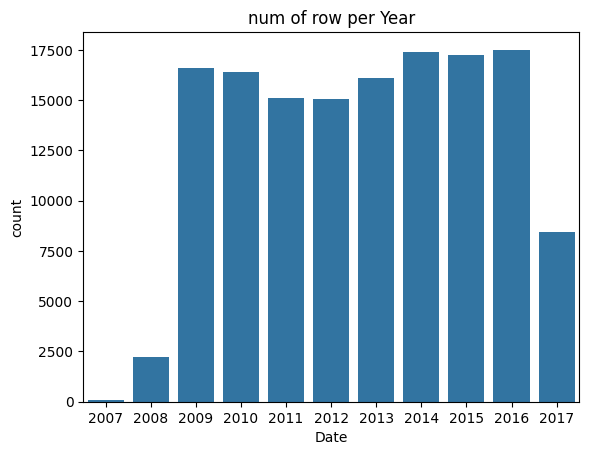

In [131]:
plt.title('num of row per Year')
sns.countplot(x=pd.to_datetime(df.Date).dt.year)

In [132]:
year =pd.to_datetime(df.Date).dt.year
train_df = df[year < 2015]
val_df = df[year == 2015]
test_df = df[year > 2015]

** input & traget cols **

In [133]:
inputs_cols = list(train_df.columns)[1:-1]
traget_cols = 'RainTomorrow'

In [134]:
train_inputs = train_df[inputs_cols].copy()
train_traget = train_df[traget_cols].copy()

In [135]:
val_inputs = val_df[inputs_cols].copy()
val_traget = val_df[traget_cols].copy()

In [136]:
test_inputs = test_df[inputs_cols].copy()
test_traget = test_df[traget_cols].copy()

numerc & categorical columns imputing

In [137]:
numerc_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categoric_cols = train_inputs.select_dtypes('object').columns.tolist()

In [138]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy= 'mean').fit(df[numerc_cols])

In [139]:
train_inputs[numerc_cols] = imputer.transform(train_inputs[numerc_cols])
val_inputs[numerc_cols] = imputer.transform(val_inputs[numerc_cols])
test_inputs[numerc_cols] = imputer.transform(test_inputs[numerc_cols])

In [140]:
train_inputs[numerc_cols].isna().sum()

,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustSpeed,0
WindSpeed9am,0
WindSpeed3pm,0
Humidity9am,0
Humidity3pm,0


In [141]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler().fit(df[numerc_cols])

In [142]:
train_inputs[numerc_cols] = scaler.transform(train_inputs[numerc_cols])
val_inputs[numerc_cols] = scaler.transform(val_inputs[numerc_cols])
test_inputs[numerc_cols] = scaler.transform(test_inputs[numerc_cols])

In [143]:
train_df[categoric_cols]= train_df[categoric_cols].fillna('unknown')
val_df[categoric_cols] = val_df[categoric_cols].fillna('unknown')
test_df[categoric_cols]= test_df[categoric_cols].fillna('unknown')

/tmp/ipython-input-1434240966.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[categoric_cols]= train_df[categoric_cols].fillna('unknown')
/tmp/ipython-input-1434240966.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df[categoric_cols] = val_df[categoric_cols].fillna('unknown')
/tmp/ipython-input-1434240966.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docum

In [144]:
test_df[categoric_cols].isna().sum()

,0
Location,0
WindGustDir,0
WindDir9am,0
WindDir3pm,0
RainToday,0


In [145]:
from sklearn.preprocessing import OneHotEncoder
encodre = OneHotEncoder(sparse_output = False , handle_unknown ='ignore').fit(df[categoric_cols])

In [146]:
encoded_cols = list(encodre.get_feature_names_out(categoric_cols))
encoded_cols

['Location_Adelaide',
 'Location_Albany',
 'Location_Albury',
 'Location_AliceSprings',
 'Location_BadgerysCreek',
 'Location_Ballarat',
 'Location_Bendigo',
 'Location_Brisbane',
 'Location_Cairns',
 'Location_Canberra',
 'Location_Cobar',
 'Location_CoffsHarbour',
 'Location_Dartmoor',
 'Location_Darwin',
 'Location_GoldCoast',
 'Location_Hobart',
 'Location_Katherine',
 'Location_Launceston',
 'Location_Melbourne',
 'Location_MelbourneAirport',
 'Location_Mildura',
 'Location_Moree',
 'Location_MountGambier',
 'Location_MountGinini',
 'Location_Newcastle',
 'Location_Nhil',
 'Location_NorahHead',
 'Location_NorfolkIsland',
 'Location_Nuriootpa',
 'Location_PearceRAAF',
 'Location_Penrith',
 'Location_Perth',
 'Location_PerthAirport',
 'Location_Portland',
 'Location_Richmond',
 'Location_Sale',
 'Location_SalmonGums',
 'Location_Sydney',
 'Location_SydneyAirport',
 'Location_Townsville',
 'Location_Tuggeranong',
 'Location_Uluru',
 'Location_WaggaWagga',
 'Location_Walpole',
 'Locat

In [147]:
train_inputs[encoded_cols] = encodre.transform(train_inputs[categoric_cols])
val_inputs[encoded_cols] = encodre.transform(val_inputs[categoric_cols])
test_inputs[encoded_cols] = encodre.transform(test_inputs[categoric_cols])

/tmp/ipython-input-2700753227.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encodre.transform(train_inputs[categoric_cols])
/tmp/ipython-input-2700753227.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encodre.transform(train_inputs[categoric_cols])
/tmp/ipython-input-2700753227.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at o

In [148]:
x_train = train_inputs[encoded_cols + numerc_cols].copy()
x_val = val_inputs[encoded_cols + numerc_cols].copy()
x_test = test_inputs[encoded_cols + numerc_cols].copy()

training model

In [149]:
from sklearn.tree import DecisionTreeClassifier
model  = DecisionTreeClassifier(random_state= 42)

In [150]:
model.fit(x_train , train_traget)

DecisionTreeClassifier(random_state=42)

In [151]:
from sklearn.metrics import accuracy_score , confusion_matrix


In [152]:
train_predict = model.predict(x_train)

In [153]:
accuracy_score(train_predict , train_traget)

0.9999797955307714

In [154]:
model.score(x_val , val_traget)

0.7913644013696245

In [155]:
from sklearn.tree import plot_tree , export_text

[Text(0.5, 0.875, 'Humidity3pm <= 0.715\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]'),
 Text(0.25, 0.625, 'Rainfall <= 0.004\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Sunshine <= 0.525\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Humidity3pm <= 0.512\ngini = 0.438\nsamples = 13166\nvalue = [8901, 4265]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Humidity3pm <= 0.825\ngini = 0.47\nsamples = 16570\nvalue = [6266, 10304]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'WindGustSpeed <= 0.279\ngini = 0.499\nsamples = 9136\nvalue = [4804, 4332]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Rainfall <= 0.01\ngini = 0.316\nsamples = 7434\nvalue = [1462, 5972]'),
 Text(0.8125, 0.125,

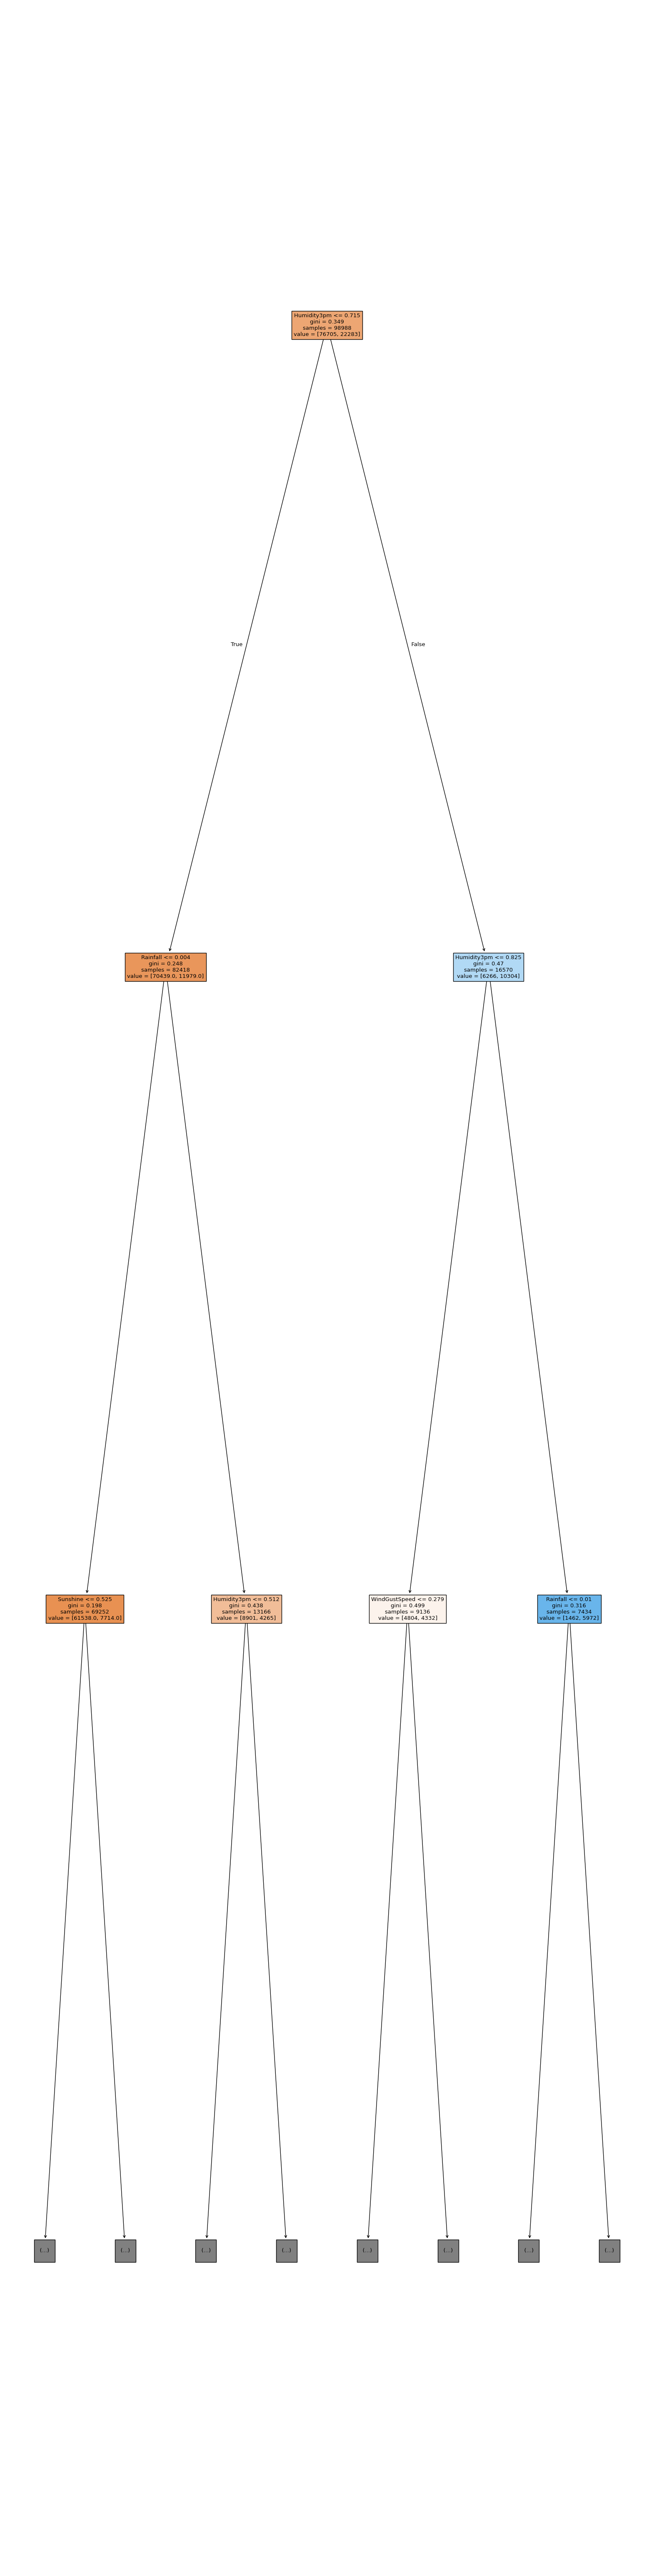

In [156]:
plt.figure(figsize=(20,80))
plot_tree(model , feature_names = x_train.columns , max_depth=2 , filled = True)

In [157]:
imporatnc_df = pd.DataFrame({
     'feature': x_train.columns,
     'importance': model.feature_importances_
 }).sort_values('importance', ascending = False)

<Axes: title={'center': 'featuer importance'}, xlabel='importance', ylabel='feature'>

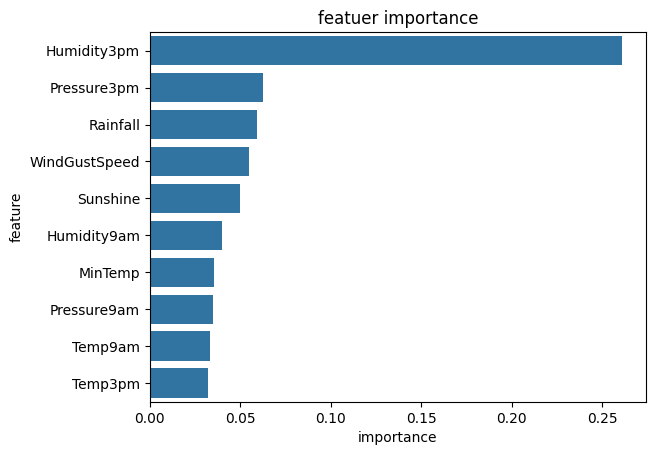

In [158]:
plt.title('featuer importance')
sns.barplot(data= imporatnc_df.head(10), x='importance', y ='feature')

# reguralization model

In [159]:
model = DecisionTreeClassifier(max_depth=10 , random_state =42)

In [160]:
model.fit(x_train , train_traget)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [161]:
model.score(x_train , train_traget)

0.86706469471047

In [162]:
model.score(x_val , val_traget)

0.8421449712727062

[Text(0.5, 0.875, 'Humidity3pm <= 0.715\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]'),
 Text(0.25, 0.625, 'Rainfall <= 0.004\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Sunshine <= 0.525\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Humidity3pm <= 0.512\ngini = 0.438\nsamples = 13166\nvalue = [8901, 4265]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Humidity3pm <= 0.825\ngini = 0.47\nsamples = 16570\nvalue = [6266, 10304]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'WindGustSpeed <= 0.279\ngini = 0.499\nsamples = 9136\nvalue = [4804, 4332]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Rainfall <= 0.01\ngini = 0.316\nsamples = 7434\nvalue = [1462, 5972]'),
 Text(0.8125, 0.125,

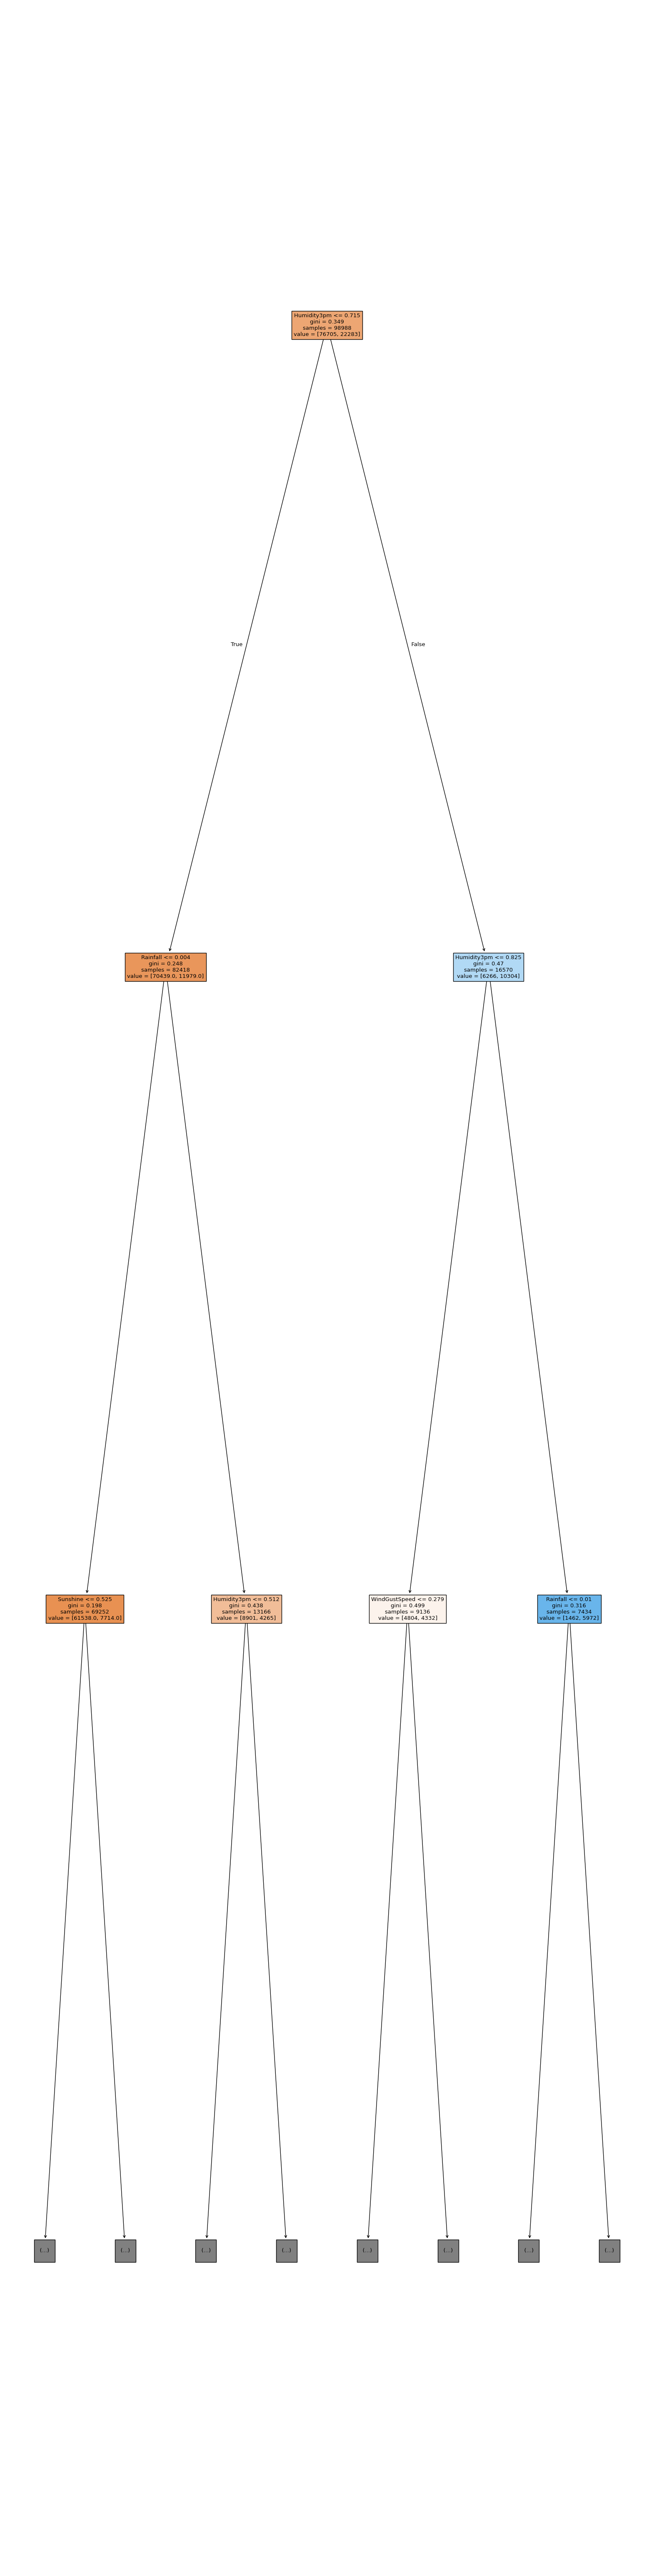

In [163]:
plt.figure(figsize=(20,80))
plot_tree(model , feature_names = x_train.columns , max_depth=2, filled = True)

In [164]:
def max_depth_error(md):
  model = DecisionTreeClassifier(max_depth=md , random_state =42)
  model.fit(x_train , train_traget)
  train_error= 1- model.score(x_train , train_traget)
  val_eror= 1- model.score(x_val , val_traget)
  return{'max_depth': md , 'training error': train_error ,'validation error': val_eror}


In [165]:
error_df= pd.DataFrame([max_depth_error(md) for md in range(1,21)])

In [166]:
error_df

,max_depth,training error,validation error
0,1,0.184315,0.177935
1,2,0.179547,0.172712
2,3,0.170869,0.166560
3,4,0.165707,0.164355
4,5,0.160676,0.159074
5,6,0.156271,0.157275
6,7,0.153312,0.154605
7,8,0.147806,0.157913
8,9,0.140916,0.156578
9,10,0.132935,0.157855


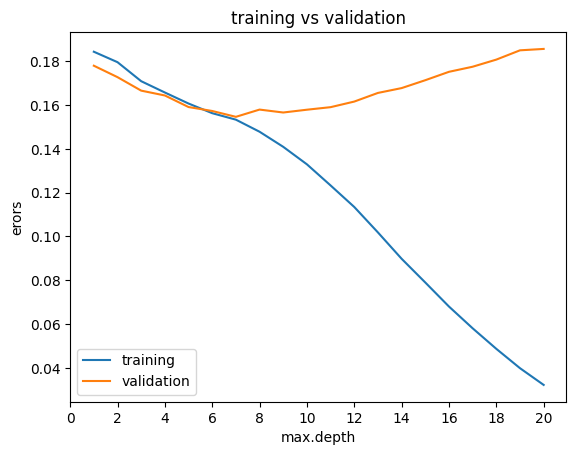

In [168]:
plt.figure()
plt.plot(error_df['max_depth'], error_df['training error'])
plt.plot(error_df['max_depth'], error_df['validation error'])
plt.title('training vs validation')
plt.xticks(range(0,21,2))
plt.xlabel('max.depth')
plt.ylabel('erors')
plt.legend(['training', 'validation'])

# max_leaf node

In [169]:
def max_leaf_error(mlf):
  model = DecisionTreeClassifier(max_leaf_nodes=mlf , random_state =42)
  model.fit(x_train , train_traget)
  train_error= 1- model.score(x_train , train_traget)
  val_eror= 1- model.score(x_val , val_traget)
  return{'max_leaf_nodes': mlf , 'training error': train_error ,'validation error': val_eror}


In [170]:
errorleaf_df = pd.DataFrame([max_leaf_error(2**n) for n in range(1, 13)])

In [171]:
errorleaf_df

,max_leaf_nodes,training error,validation error
0,2,0.184315,0.177935
1,4,0.179547,0.172712
2,8,0.170869,0.166560
3,16,0.165707,0.164355
4,32,0.158777,0.159190
5,64,0.155989,0.156752
6,128,0.151958,0.155766
7,256,0.142492,0.156752
8,512,0.130703,0.155650
9,1024,0.114832,0.158377


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['max_leaf_nodes'].plot(kind='hist', bins=20, title='max_leaf_nodes')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['training error'].plot(kind='hist', bins=20, title='training error')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['validation error'].plot(kind='hist', bins=20, title='validation error')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['max_leaf_nodes']
  ys = series['training error']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_10.sort_values('max_leaf_nodes', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('max_leaf_nodes')
_ = plt.ylabel('training error')

from matplotlib import pyplot as plt
_df_11['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_12['max_leaf_nodes'].plot(kind='line', figsize=(8, 4), title='max_leaf_nodes')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['training error'].plot(kind='line', figsize=(8, 4), title='training error')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['validation error'].plot(kind='line', figsize=(8, 4), title='validation error')
plt.gca().spines[['top', 'right']].set_visible(False)

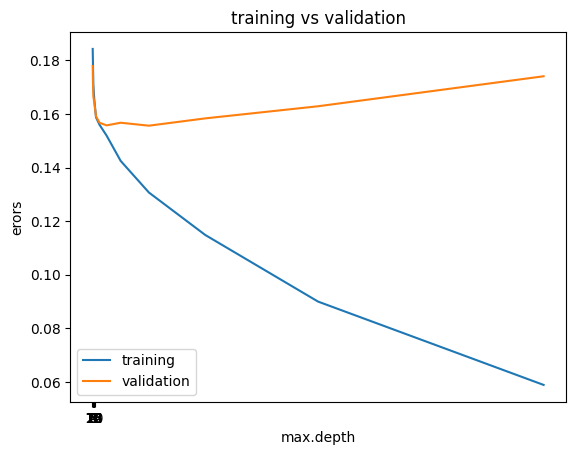

In [173]:
plt.figure()
plt.plot(errorleaf_df ['max_leaf_nodes'], errorleaf_df ['training error'])
plt.plot(errorleaf_df ['max_leaf_nodes'], errorleaf_df ['validation error'])
plt.title('training vs validation')
plt.xticks(range(0,21,2))
plt.xlabel('max.depth')
plt.ylabel('erors')
plt.legend(['training', 'validation'])